# ResNet-18 (Augmented v1)

**Objective**: Reduce the heavy overfitting observed in the unfrozen baseline by introducing stronger data augmentation and a learning rate scheduler. This experiment tests if constrained optimization and more varied training samples can help the model generalize better to the subtle visual patterns of melanoma.

**Architecture Changes**:
| Component | Previous iteration (Unfreeze) | This iteration (Augmented v1) |
|---|---|---|
| Augmentation | HFlip + ±10° rotation | HFlip + VFlip + ±30° rotation + ColorJitter + RandomAffine |
| Weight decay | 0 | 1e-4 |
| LR scheduler | None | CosineAnnealingLR |
| Optimizer | Adam | Adam |
| Trainable params | ~11.2M | ~11.2M |
| Epochs | 20 | 20 |

**Hypothesis**: Stronger augmentation (especially vertical flips and affine shifts) will act as a strong regularizer for skin lesion images, which have no natural orientation. Combined with weight decay and a cosine annealing scheduler, the train/val gap should narrow, and recall should improve as the model is forced to learn more robust features.

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
model = get_resnet(num_classes=1, freeze_backbone=False).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 20
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

L1_LAMBDA = 0.0
L2_LAMBDA = 0.0
dropout = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {dropout}')

Trainable params: 11,177,025 / 11,177,025
L1 lambda: 0.0 | L2 lambda: 0.0 | Dropout: 0.0


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/resnet_augmented_v1_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/20]
  Train | Loss: 0.9121, Bal Acc: 0.7462, Recall: 0.7959, F2: 0.5483, AUC: 0.8244
  Val   | Loss: 0.9108, Bal Acc: 0.7556, Recall: 0.6907, F2: 0.5707, AUC: 0.8560
  -> Saved best model (val AUC: 0.8560)


Epoch [2/20]
  Train | Loss: 0.7897, Bal Acc: 0.7878, Recall: 0.8461, F2: 0.6009, AUC: 0.8667
  Val   | Loss: 0.7867, Bal Acc: 0.7828, Recall: 0.8983, F2: 0.6054, AUC: 0.8804
  -> Saved best model (val AUC: 0.8804)


Epoch [3/20]
  Train | Loss: 0.7541, Bal Acc: 0.7978, Recall: 0.8347, F2: 0.6162, AUC: 0.8828
  Val   | Loss: 0.7878, Bal Acc: 0.7880, Recall: 0.7627, F2: 0.6173, AUC: 0.8852
  -> Saved best model (val AUC: 0.8852)


Epoch [4/20]
  Train | Loss: 0.7189, Bal Acc: 0.8096, Recall: 0.8540, F2: 0.6319, AUC: 0.8931
  Val   | Loss: 0.7508, Bal Acc: 0.7855, Recall: 0.8517, F2: 0.6102, AUC: 0.8862
  -> Saved best model (val AUC: 0.8862)


Epoch [5/20]
  Train | Loss: 0.6943, Bal Acc: 0.8175, Recall: 0.8575, F2: 0.6436, AUC: 0.9000
  Val   | Loss: 0.8233, Bal Acc: 0.7946, Recall: 0.7754, F2: 0.6267, AUC: 0.8830


...

Epoch [16/20]
  Train | Loss: 0.3724, Bal Acc: 0.9126, Recall: 0.9327, F2: 0.8034, AUC: 0.9726
  Val   | Loss: 0.8859, Bal Acc: 0.8091, Recall: 0.7373, F2: 0.6536, AUC: 0.9122
  -> Saved best model (val AUC: 0.9122)


Epoch [17/20]
  Train | Loss: 0.3462, Bal Acc: 0.9249, Recall: 0.9475, F2: 0.8252, AUC: 0.9759
  Val   | Loss: 0.8943, Bal Acc: 0.8375, Recall: 0.8008, F2: 0.6959, AUC: 0.9123
  -> Saved best model (val AUC: 0.9123)


Epoch [18/20]
  Train | Loss: 0.3180, Bal Acc: 0.9289, Recall: 0.9498, F2: 0.8337, AUC: 0.9797
  Val   | Loss: 0.9746, Bal Acc: 0.7994, Recall: 0.7119, F2: 0.6393, AUC: 0.9088


Epoch [19/20]
  Train | Loss: 0.3119, Bal Acc: 0.9314, Recall: 0.9521, F2: 0.8385, AUC: 0.9807
  Val   | Loss: 0.9492, Bal Acc: 0.8179, Recall: 0.7415, F2: 0.6690, AUC: 0.9127
  -> Saved best model (val AUC: 0.9127)


Epoch [20/20]
  Train | Loss: 0.2977, Bal Acc: 0.9386, Recall: 0.9658, F2: 0.8495, AUC: 0.9820
  Val   | Loss: 0.9751, Bal Acc: 0.8099, Recall: 0.7288, F2: 0.6560, AUC: 0.9112


## Plot Train and Validation Curves

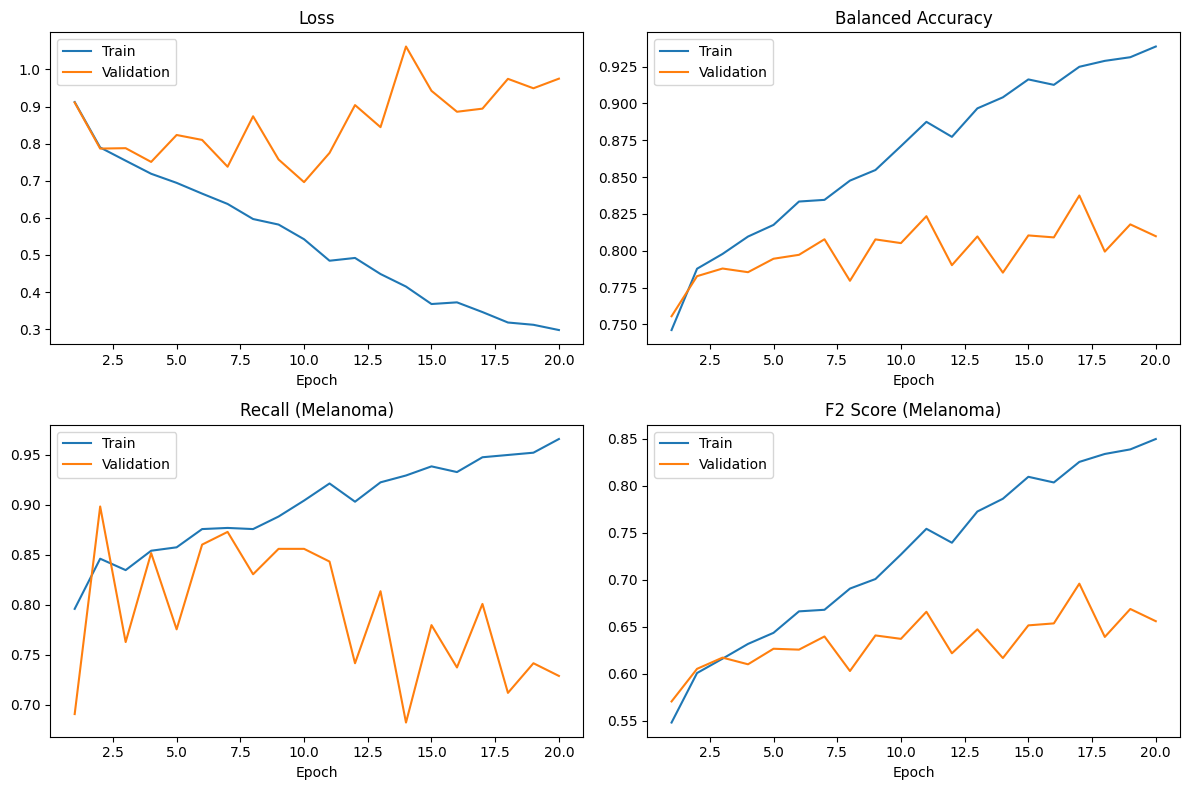

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/resnet_augmented_v1_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.41 | Val F2: 0.6907


## Test Set Evaluation

Threshold:          0.41
AUC-ROC:            0.9190
Balanced Accuracy:  0.8215
F2 Score:           0.6684

              precision    recall  f1-score   support

Non-Melanoma     0.9671    0.8769    0.9198      1340
    Melanoma     0.4426    0.7661    0.5610       171

    accuracy                         0.8643      1511
   macro avg     0.7048    0.8215    0.7404      1511
weighted avg     0.9077    0.8643    0.8792      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


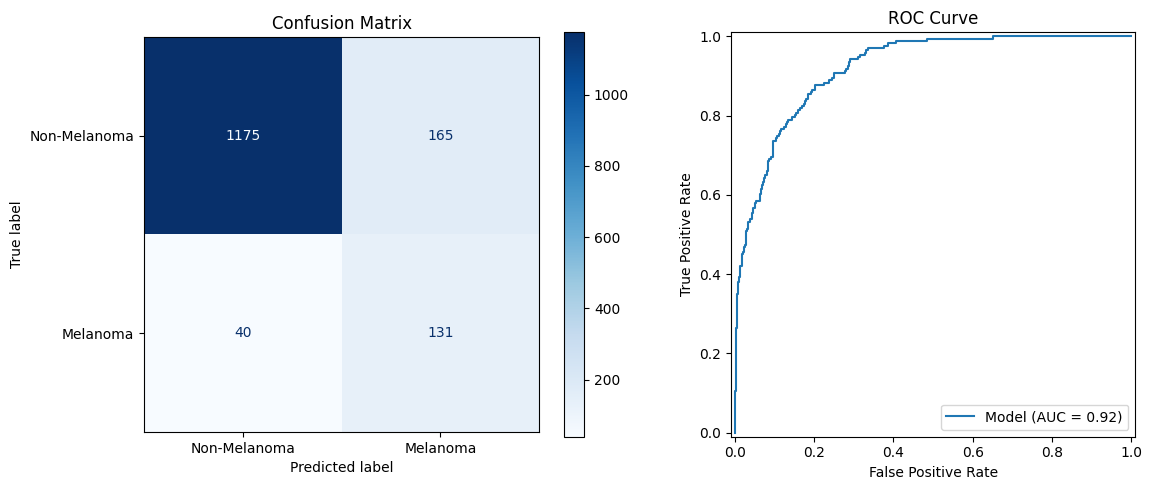

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold)